### Human Cognitive Performance Analysis


# 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings

# Suppress warnings for cleaner outputs
warnings.filterwarnings("ignore")

# Set Seaborn style
sns.set(style="whitegrid")


# 2. Load Dataset
We start by loading the dataset and examining its structure.

In [ ]:
df = pd.read_csv(r'human_cognitive_performance.csv')
df.head()

,User_ID,Age,Gender,Sleep_Duration,Stress_Level,Diet_Type,Daily_Screen_Time,Exercise_Frequency,Caffeine_Intake,Reaction_Time,Memory_Test_Score,Cognitive_Score,AI_Predicted_Score
0,U1,57,Female,6.5,3,Non-Vegetarian,6.5,Medium,41,583.33,65,36.71,39.77
1,U2,39,Female,7.6,9,Non-Vegetarian,10.8,High,214,368.24,58,54.35,57.68
2,U3,26,Male,8.2,6,Vegetarian,5.7,Low,429,445.21,49,32.57,29.54
3,U4,32,Male,7.8,9,Vegetarian,8.3,Low,464,286.33,94,70.15,74.59
4,U5,50,Male,9.7,2,Non-Vegetarian,11.3,Medium,365,237.65,62,87.54,91.78


# 3. Initial Exploration
Check dataset shape, column types, missing values, duplicates, and basic statistics.

In [ ]:
print("Dataset shape:", df.shape)
print("\nColumn types:\n", df.dtypes.value_counts())
print("\nMissing values per column:\n", df.isnull().sum())
print("\nNumber of duplicated rows:", df.duplicated().sum())
df.describe()

Dataset shape: (80000, 13)

Column types:
 float64    5
str        4
int64      4
Name: count, dtype: int64

Missing values per column:
 User_ID               0
Age                   0
Gender                0
Sleep_Duration        0
Stress_Level          0
Diet_Type             0
Daily_Screen_Time     0
Exercise_Frequency    0
Caffeine_Intake       0
Reaction_Time         0
Memory_Test_Score     0
Cognitive_Score       0
AI_Predicted_Score    0
dtype: int64

Number of duplicated rows: 0


,Age,Sleep_Duration,Stress_Level,Daily_Screen_Time,Caffeine_Intake,Reaction_Time,Memory_Test_Score,Cognitive_Score,AI_Predicted_Score
count,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000
mean,38.525525,7.005333,5.493762,6.504646,248.988213,399.973579,69.498350,58.172395,58.121357
std,12.101876,1.734435,2.865308,3.167072,144.541990,115.369329,17.305659,23.058522,23.119598
min,18.000000,4.000000,1.000000,1.000000,0.000000,200.000000,40.000000,0.000000,0.000000
25%,28.000000,5.500000,3.000000,3.800000,123.000000,300.150000,55.000000,40.910000,40.850000
50%,39.000000,7.000000,5.000000,6.500000,249.000000,400.360000,70.000000,58.360000,58.360000
75%,49.000000,8.500000,8.000000,9.200000,375.000000,499.250000,85.000000,75.830000,75.890000
max,59.000000,10.000000,10.000000,12.000000,499.000000,599.990000,99.000000,100.000000,100.000000


# 4. Data Cleaning and Copy
Drop non-essential columns and keep a copy for safe operations.

In [ ]:
df_copy = df.copy()
df_copy.drop(['User_ID', 'AI_Predicted_Score'], axis=1, inplace=True)
df_copy.head()

,Age,Gender,Sleep_Duration,Stress_Level,Diet_Type,Daily_Screen_Time,Exercise_Frequency,Caffeine_Intake,Reaction_Time,Memory_Test_Score,Cognitive_Score
0,57,Female,6.5,3,Non-Vegetarian,6.5,Medium,41,583.33,65,36.71
1,39,Female,7.6,9,Non-Vegetarian,10.8,High,214,368.24,58,54.35
2,26,Male,8.2,6,Vegetarian,5.7,Low,429,445.21,49,32.57
3,32,Male,7.8,9,Vegetarian,8.3,Low,464,286.33,94,70.15
4,50,Male,9.7,2,Non-Vegetarian,11.3,Medium,365,237.65,62,87.54


# 5. Encode Categorical Variables
Machine learning models cannot process strings, so we encode categorical columns numerically.

In [ ]:
df_copy['Gender'] = df_copy['Gender'].map({'Male': 0, 'Female': 1, 'Other': 2})
df_copy['Diet_Type'] = df_copy['Diet_Type'].map({'Vegetarian': 0, 'Non-Vegetarian': 1, 'Vegan': 2})
df_copy['Exercise_Frequency'] = df_copy['Exercise_Frequency'].map({'Low': 0, 'Medium': 1, 'High': 2})
df_copy.head()

,Age,Gender,Sleep_Duration,Stress_Level,Diet_Type,Daily_Screen_Time,Exercise_Frequency,Caffeine_Intake,Reaction_Time,Memory_Test_Score,Cognitive_Score
0,57,1,6.5,3,1,6.5,1,41,583.33,65,36.71
1,39,1,7.6,9,1,10.8,2,214,368.24,58,54.35
2,26,0,8.2,6,0,5.7,0,429,445.21,49,32.57
3,32,0,7.8,9,0,8.3,0,464,286.33,94,70.15
4,50,0,9.7,2,1,11.3,1,365,237.65,62,87.54


# 6. Exploratory Data Analysis (EDA)
We visualize distributions, correlations, and relationships between features.

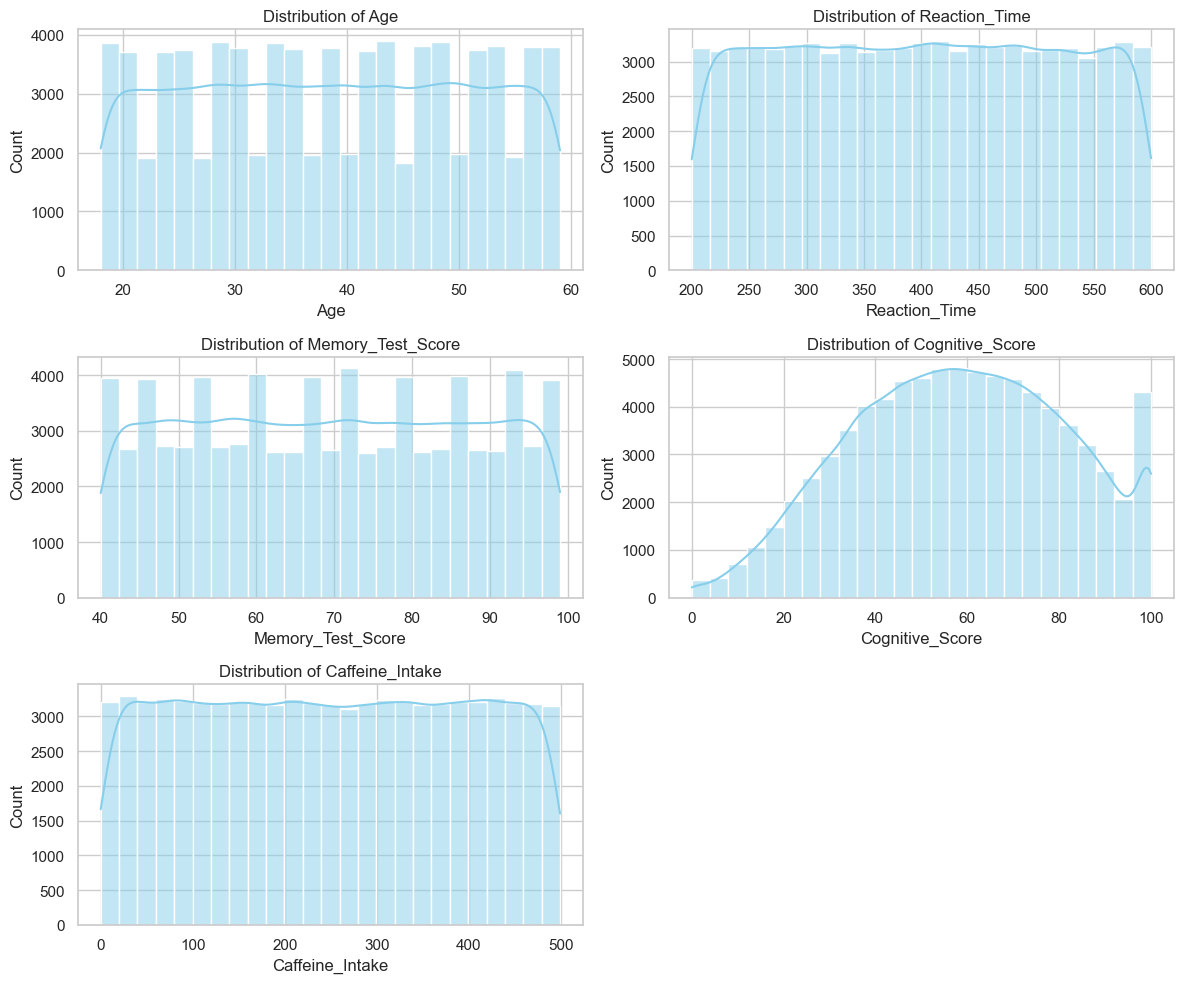

In [ ]:
# Numerical features
num_features = ['Age', 'Reaction_Time', 'Memory_Test_Score', 'Cognitive_Score', 'Caffeine_Intake']

# Histogram + KDE plots
plt.figure(figsize=(12, 10))
for i, col in enumerate(num_features, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df_copy[col], kde=True, bins=25, color='skyblue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

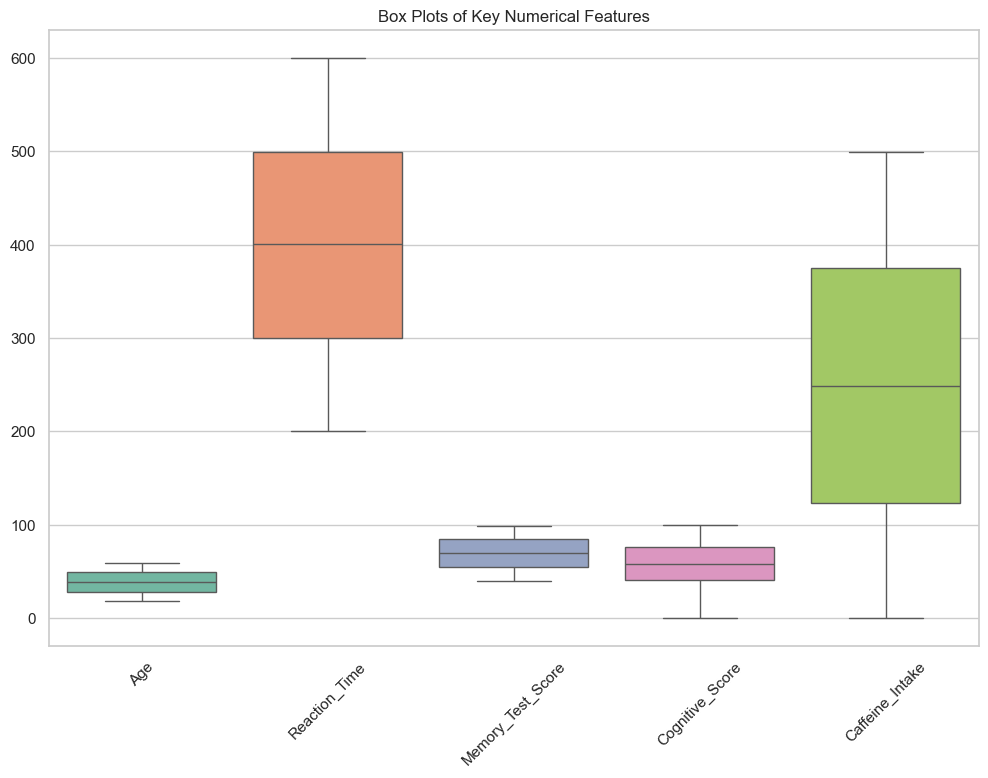

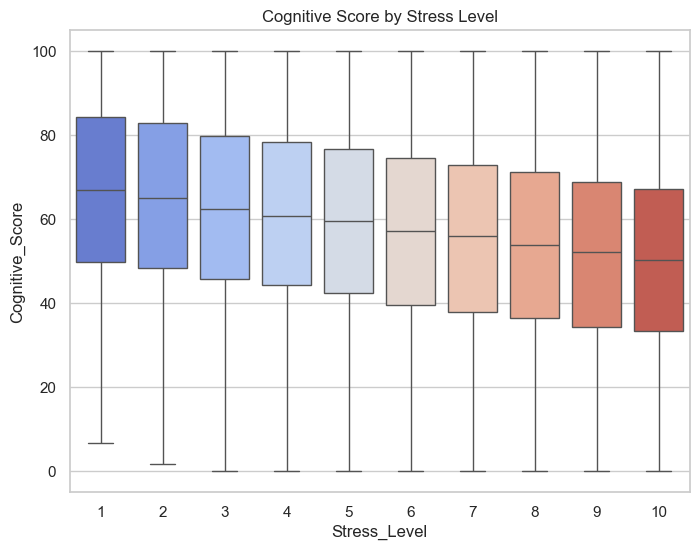

In [ ]:
# Box plots to identify outliers
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_copy[num_features], palette="Set2")
plt.title("Box Plots of Key Numerical Features")
plt.xticks(rotation=45)
plt.show()

# Box plot for Cognitive Score by Stress Level
plt.figure(figsize=(8, 6))
sns.boxplot(x='Stress_Level', y='Cognitive_Score', data=df_copy, palette="coolwarm")
plt.title("Cognitive Score by Stress Level")
plt.show()

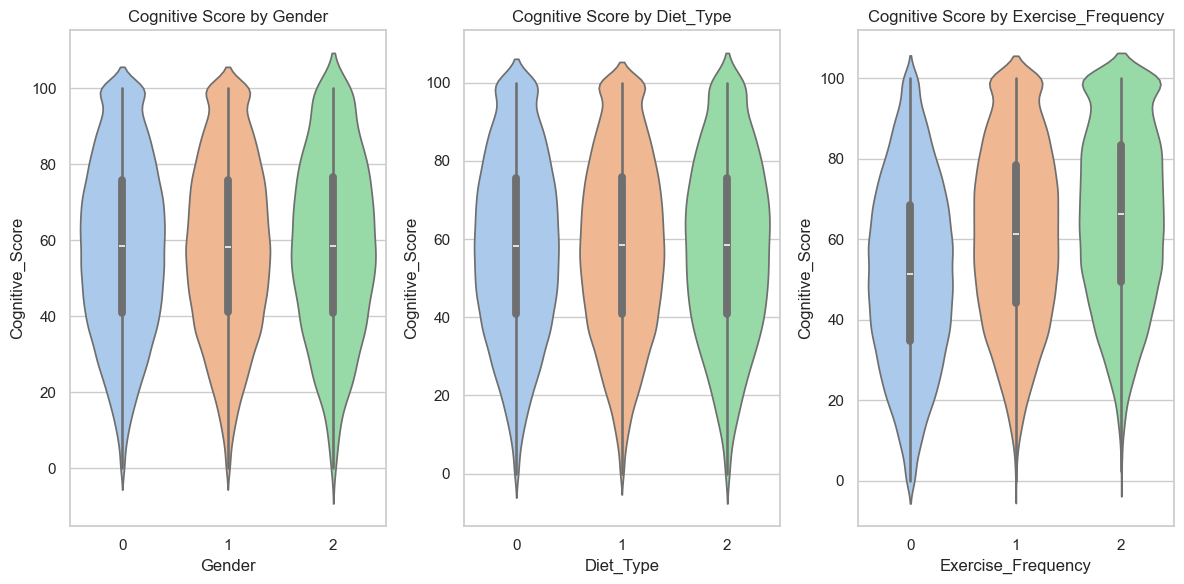

In [ ]:
# Violin plots for categorical features
cat_features = ['Gender', 'Diet_Type', 'Exercise_Frequency']

plt.figure(figsize=(12, 6))
for i, feature in enumerate(cat_features, 1):
    plt.subplot(1, 3, i)
    sns.violinplot(x=feature, y='Cognitive_Score', data=df_copy, palette="pastel")
    plt.title(f'Cognitive Score by {feature}')
plt.tight_layout()
plt.show()

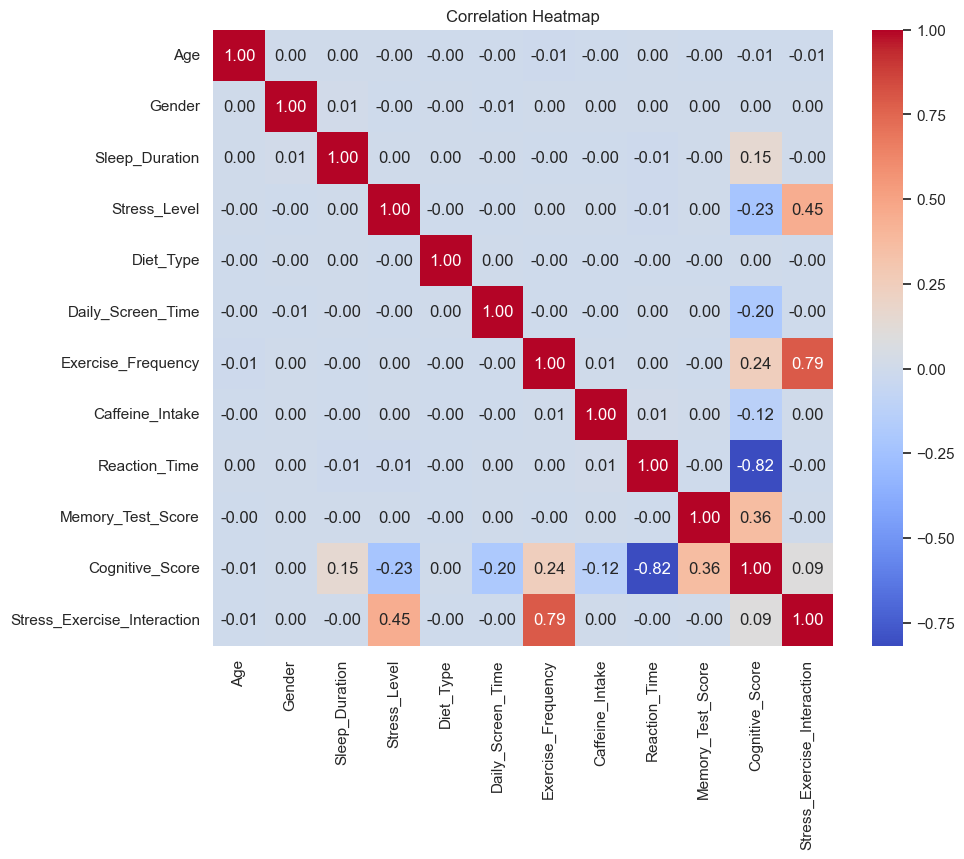

,Age,Gender,Sleep_Duration,Stress_Level,Diet_Type,Daily_Screen_Time,Exercise_Frequency,Caffeine_Intake,Reaction_Time,Memory_Test_Score,Cognitive_Score,Stress_Exercise_Interaction
0,57,1,6.5,3,1,6.5,1,41,583.33,65,36.71,3
1,39,1,7.6,9,1,10.8,2,214,368.24,58,54.35,18
2,26,0,8.2,6,0,5.7,0,429,445.21,49,32.57,0
3,32,0,7.8,9,0,8.3,0,464,286.33,94,70.15,0
4,50,0,9.7,2,1,11.3,1,365,237.65,62,87.54,2


In [ ]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_copy.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()
df_copy.head()

# 7. Feature Engineering (Optional)
We create a new feature combining stress and exercise frequency to explore interactions.

In [ ]:
df_copy['Stress_Exercise_Interaction'] = df_copy['Stress_Level'] * df_copy['Exercise_Frequency']

# 8. Mini Predictive Modeling
Predict Cognitive Score using Linear Regression and Random Forest.

In [ ]:
# Define features and target
features = ['Age', 'Reaction_Time', 'Memory_Test_Score', 'Caffeine_Intake', 
            'Gender', 'Diet_Type', 'Exercise_Frequency', 'Stress_Level', 'Stress_Exercise_Interaction']
X = df_copy[features]
y = df_copy['Cognitive_Score']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Linear Regression R2:", r2_score(y_test, y_pred_lr))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

# Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest R2:", r2_score(y_test, y_pred_rf))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Linear Regression R2: 0.9310668934423993
Linear Regression RMSE: 6.027359848922693
Random Forest R2: 0.9284155273328971
Random Forest RMSE: 6.1421810005444115


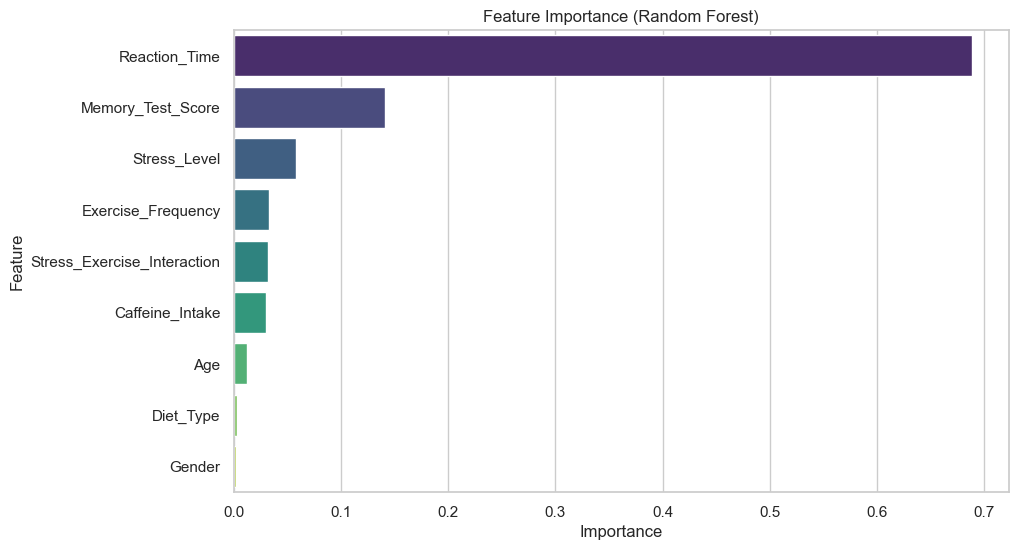

In [ ]:
# Feature importance from Random Forest
importances = rf.feature_importances_
feat_importances = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feat_importances, y=feat_importances.index, palette="viridis")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# 9. Save Cleaned Dataset
Saving the processed dataset for reproducibility.

In [ ]:
df_copy.to_csv('human_cognitive_performance_cleaned.csv', index=False)